In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import keras
import tensorflow as tf
from tensorflow.keras.utils import img_to_array,load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Flatten
from keras.models import Model
from keras.applications.inception_v3 import InceptionV3,preprocess_input
from sklearn.model_selection import train_test_split

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Data Augmentation

In [6]:
# import os
# import shutil
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from sklearn.model_selection import train_test_split
# from tensorflow.keras.preprocessing import image

# # Directories
# output_dir = "/content/drive/MyDrive/Scoliosis_Detection/Scol_Spon_Normal_Dataset_256x256/Preprocesseddata"
# train_dir = os.path.join(output_dir, "train")
# val_dir = os.path.join(output_dir, "val")
# test_dir = os.path.join(output_dir, "test")

# # Create output directories
# for directory in [train_dir, val_dir, test_dir]:
#     if not os.path.exists(directory):
#         os.makedirs(directory)

# # Augmentation configuration
# datagen = ImageDataGenerator(
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     fill_mode="nearest"
# )

# # Augment and split data
# for class_name in os.listdir(folder_dir):
#     class_path = os.path.join(folder_dir, class_name)
#     if not os.path.isdir(class_path):
#         continue

#     images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('.jpg', '.png', '.jpeg'))]

#     # Split data
#     train_images, temp_images = train_test_split(images, test_size=0.3, random_state=42)
#     val_images, test_images = train_test_split(temp_images, test_size=0.33, random_state=42)  # 20% val, 10% test

#     # Create class-specific folders
#     os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

#     # Copy and augment training images
#     for img_path in train_images:
#         # Load and augment the image
#         img = image.load_img(img_path, target_size=(256, 256))  # Load image
#         x = image.img_to_array(img)  # Convert to numpy array
#         x = x.reshape((1,) + x.shape)  # Reshape to (1, height, width, channels)

#         # Generate augmented images and save
#         i = 0
#         for batch in datagen.flow(x, batch_size=1,
#                                   save_to_dir=os.path.join(train_dir, class_name),
#                                   save_prefix='aug', save_format='jpeg'):
#             i += 1
#             if i > 20:  # Generate 20 augmented images per original image
#                 break

#     # Copy validation and test images
#     for img_path, dest_dir in zip([val_images, test_images], [val_dir, test_dir]):
#         for img in img_path:
#             shutil.copy(img, os.path.join(dest_dir, class_name, os.path.basename(img)))

In [8]:
folder_dir = "/content/drive/MyDrive/Scoliosis_Detection/Scol_Spon_Normal_Dataset_256x256/Preprocesseddata/train"
folder_dir2 = "/content/drive/MyDrive/Scoliosis_Detection/Scol_Spon_Normal_Dataset_256x256/Preprocesseddata/val"

In [9]:
train_datagen=ImageDataGenerator(featurewise_center=True,
                                 rotation_range=0.4,
                                 width_shift_range=0.3,
                                horizontal_flip=True,
                                preprocessing_function= preprocess_input,
                                  zoom_range = 0.4,
                                 shear_range=0.4
                                 )
train = train_datagen.flow_from_directory(directory=folder_dir,
                                          target_size=(256,256),
                                            batch_size=32)


val_datagen=ImageDataGenerator(featurewise_center=True,
                                 rotation_range=0.4,
                                 width_shift_range=0.3,
                                horizontal_flip=True,
                                preprocessing_function= preprocess_input,
                                  zoom_range = 0.4,
                                 shear_range=0.4 )

val=val_datagen.flow_from_directory(directory=folder_dir2,
                                     target_size=(256,256),
                                            batch_size=32)




Found 3407 images belonging to 3 classes.
Found 50 images belonging to 3 classes.


In [10]:
train

In [ ]:
#convert all images into arrays
t_img, label = next(train)

/usr/local/lib/python3.10/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


In [12]:
len(t_img[1][1])

256

In [13]:
label[1][1]

1.0

In [14]:
(t_img[1][1])

array([[-9.59304333e-01, -9.20088649e-01, -9.67147470e-01],
       [-9.59302664e-01, -9.20086980e-01, -9.67145801e-01],
       [-9.59301054e-01, -9.20085371e-01, -9.67144191e-01],
       [-9.59299386e-01, -9.20083702e-01, -9.67142522e-01],
       [-9.59297717e-01, -9.20082033e-01, -9.67140853e-01],
       [-9.59296107e-01, -9.20080423e-01, -9.67139244e-01],
       [-9.59294438e-01, -9.20078754e-01, -9.67137575e-01],
       [-9.59292769e-01, -9.20077085e-01, -9.67135906e-01],
       [-9.59291160e-01, -9.20075476e-01, -9.67134297e-01],
       [-9.59289491e-01, -9.20073807e-01, -9.67132628e-01],
       [-9.59287882e-01, -9.20072198e-01, -9.67131019e-01],
       [-9.59286213e-01, -9.20070529e-01, -9.67129350e-01],
       [-9.59284544e-01, -9.20068860e-01, -9.67127681e-01],
       [-9.59282935e-01, -9.20067191e-01, -9.67126071e-01],
       [-9.59281266e-01, -9.20065582e-01, -9.67124403e-01],
       [-9.59279597e-01, -9.20063913e-01, -9.67122734e-01],
       [-9.59277987e-01, -9.20062304e-01

In [ ]:
base_model=InceptionV3(input_shape=(256,256,3),include_top=False)  #include_top disables few layers in the top


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable=False

In [ ]:
X=Flatten()(base_model.output)
X=Dense(units=3,activation='softmax')(X) #3 classes

model=Model(base_model.input,X)

compiliing the model


In [18]:
optimiser = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimiser,loss=keras.losses.categorical_crossentropy,metrics=['accuracy'])


In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 127, 127, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 127, 127, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 127, 127, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 125, 125, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 125, 125, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 125, 125, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 125, 125, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 125, 125, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 125, 125, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 62, 62, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 62, 62, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 62, 62, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 62, 62, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 60, 60, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 60, 60, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activat

 Total params: 22,023,971 (84.01 MB)

 Trainable params: 221,187 (864.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Preprocessing the data


In [20]:
t_img.shape

(32, 256, 256, 3)

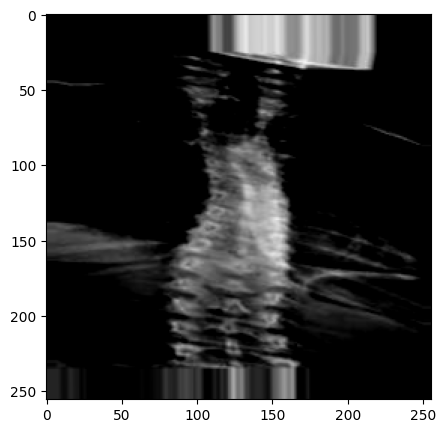

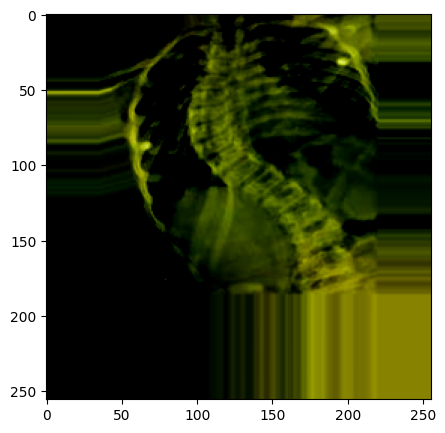

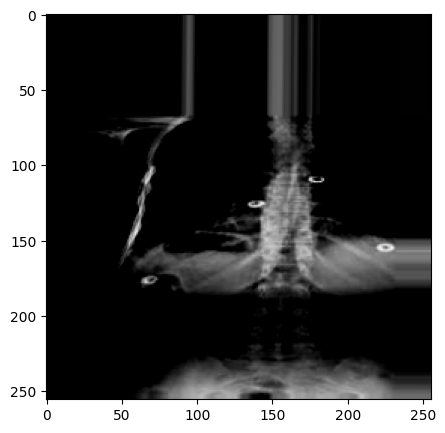

In [21]:
def plotImage(img_arr,label):
    for im , l in zip(img_arr,label):
        plt.figure(figsize=(5,5))
        (plt.imshow(im))

        (plt.show())
plotImage(t_img[:3],label[:3])


TRaining the model


In [22]:
from keras.callbacks import ModelCheckpoint,EarlyStopping
#earlystopping
es=EarlyStopping(monitor='accuracy',min_delta=0.01,patience=8,verbose=1)
es1=EarlyStopping(monitor='val_accuracy',min_delta=0.01,patience=2,verbose=1)

#model checkpoint
mc=ModelCheckpoint(filepath="best_model.keras",monitor='accuracy',
                   #min_delta=0.01,
                   #patience=8,
                   verbose=2,
                   save_best_only=True)
mc1=ModelCheckpoint(filepath="best_model2.keras",monitor='val_accuracy',
                   #min_delta=0.01,
                   #patience=10,
                   verbose=2,
                   save_best_only=True)
cb=[es,mc,es1,mc1]

In [23]:
his=model.fit(train, steps_per_epoch=25, epochs=20, verbose=1,

                    callbacks=cb,
                    validation_data=val,
                    validation_steps=20)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.5584 - loss: 1.4600
Epoch 1: accuracy improved from -inf to 0.65134, saving model to best_model.keras


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 1: val_accuracy improved from -inf to 0.84000, saving model to best_model2.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5620 - loss: 1.4435 - val_accuracy: 0.8400 - val_loss: 0.4955
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8200 - loss: 0.4272
Epoch 2: accuracy improved from 0.65134 to 0.84625, saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.84000 to 0.88000, saving model to best_model2.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 755ms/step - accuracy: 0.8210 - loss: 0.4256 - val_accuracy: 0.8800 - val_loss: 0.3249
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8825 - loss: 0.3054
Epoch 3: accuracy improved from 0.84625 to 0.90500, saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.88000 to 0.90000, saving model to best_model2.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 792ms/step - accuracy: 0.8834 - loss: 0.3036 - val_accuracy: 0.9000 - val_loss: 0.3176
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━

In [24]:
from keras.models import load_model
model=load_model("/content/best_model.keras")

In [25]:
h=his.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

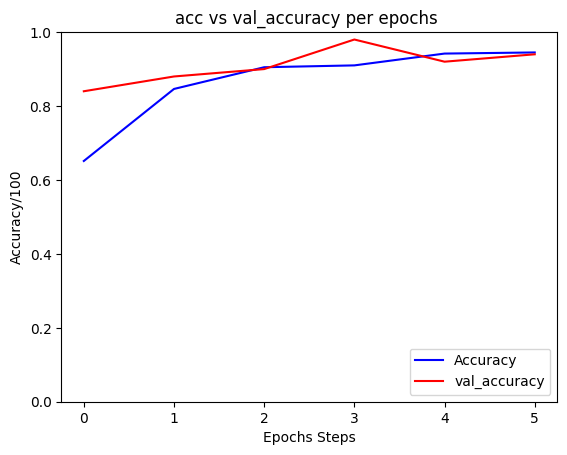

In [36]:
l1,=plt.plot(h['accuracy'],c="blue")
l2,=plt.plot(h['val_accuracy'],c="red")
plt.legend((l1,l2),["Accuracy","val_accuracy"],loc="lower right")
plt.xlabel('Epochs Steps')
plt.ylabel('Accuracy/100')
plt.title("acc vs val_accuracy per epochs ")
plt.ylim(0,1.00)
plt.show()

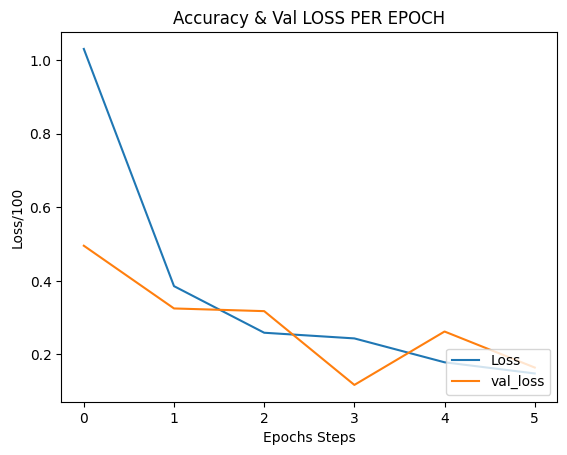

In [37]:
l1,=plt.plot(h['loss'])
l2,=plt.plot(h['val_loss'])
plt.legend((l1,l2),["Loss","val_loss"],loc="lower right")
# plt.legend(["LOSS"],loc="lower righ/8t")
plt.xlabel('Epochs Steps')
plt.ylabel('Loss/100')
plt.title("Accuracy & Val LOSS PER EPOCH")
plt.show()

In [ ]:
ref = dict(zip(list(train.class_indices.values()),list(train.class_indices.keys())))  #extract all the classes/labels inside 'train' folder


In [29]:
def prediction(path):
  img=load_img(path,target_size=(256,256))
  i=img_to_array(img)
  im=preprocess_input(i)
  # print(im.shape)
  img=np.expand_dims(im,axis=0)
  # print(img.shape)
  pred=np.argmax(model.predict(img))
  # print(pred)
  print(f"The image belongs to {ref[pred]}")

In [30]:
test_dir="/content/drive/MyDrive/Scoliosis_Detection/Scol_Spon_Normal_Dataset_256x256/Preprocesseddata/test"

In [ ]:
testing_datagen = ImageDataGenerator(rescale=1. / 255) #it is a way that the images have been taken for testing
testing_generator = testing_datagen.flow_from_directory(
    test_dir,
target_size=(256,256),
batch_size=32,
shuffle=False,
class_mode='categorical')

Found 27 images belonging to 3 classes.
Found 27 images belonging to 3 classes.


Normalized confusion matrix


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Confusion Matrix
[[ 7  1  0]
 [ 0 15  0]
 [ 0  1  3]]


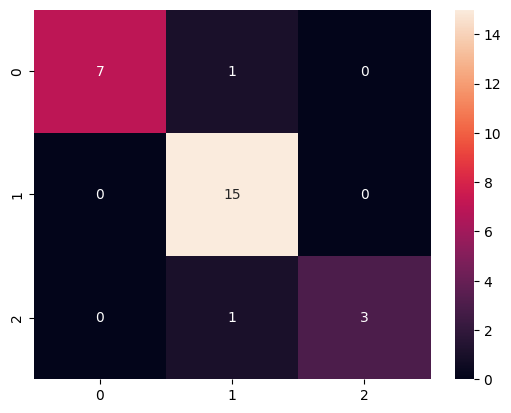

Classification Report
True positive TPs:- 7
False positive FPs:- 1
Flase negatives FNs:- 0
True Negatices TNs:- 15
Accuracy:- 0.9565217391304348
              precision    recall  f1-score   support

      Normal       1.00      0.88      0.93         8
        Scol       0.88      1.00      0.94        15
       Spond       1.00      0.75      0.86         4

    accuracy                           0.93        27
   macro avg       0.96      0.88      0.91        27
weighted avg       0.93      0.93      0.92        27



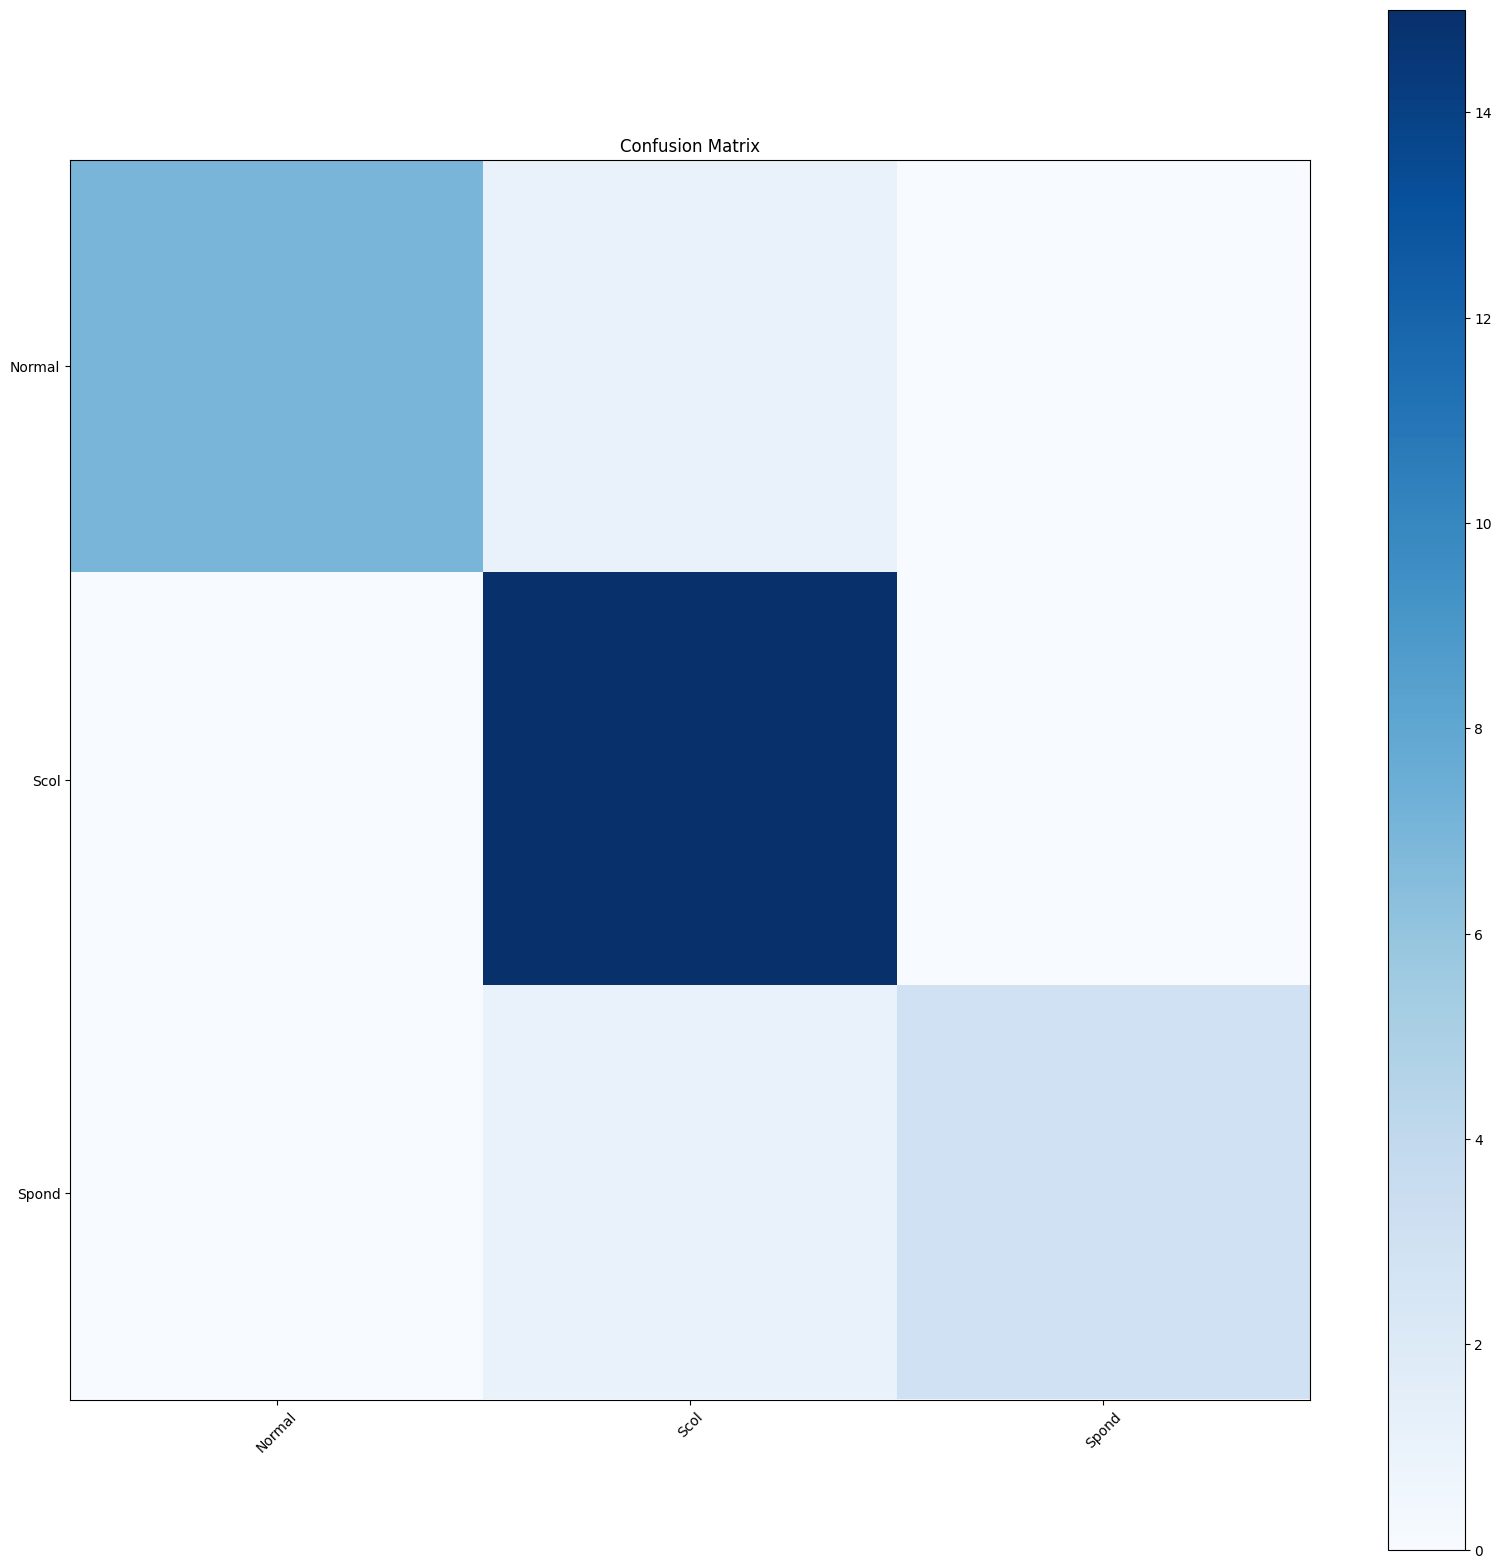

In [34]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import keras
import tensorflow as tf
import os

from sklearn.metrics import confusion_matrix as cm
normalize = True
def plot_confusion_matrix(cm, classes, normalize=True, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(20,20))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
if normalize:
        # cm = cm / cm(axis=1)
        # cm = np.round(cm, decimals=2)
        # cm[np.isnan(cm)] = 0.0
        print("Normalized confusion matrix")
else:
    print('Confusion matrix, without normalization')
    thresh = (cm.max() / 2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
#Print the Target names
from sklearn.metrics import classification_report, confusion_matrix
import itertools
#shuffle=False
target_names = []
train_generator
for key in train_generator.class_indices:
    target_names.append(key)
# print(target_names)
#Confution Matrix


# Y_pred = model.predict_generator(testing_generator)

Y_pred = model.predict(testing_generator) #changed
y_pred = np.argmax(Y_pred, axis=1)
print('Confusion Matrix')
cm = confusion_matrix(testing_generator.classes, y_pred)
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True)
plt.show()
plot_confusion_matrix(cm, target_names, title='Confusion Matrix')
#Print Classification Report
print('Classification Report')


TPs=cm[0][0]
FPs=cm[0][1]
FNs=cm[1][0]
TNs=cm[1][1]
print("True positive TPs:-",cm[0][0])
print("False positive FPs:-",cm[0][1])
print("Flase negatives FNs:-",cm[1][0])
print("True Negatices TNs:-",cm[1][1])


print("Accuracy:-",(TPs+TNs)/(TPs+FPs+FNs+TNs))


print(classification_report(testing_generator.classes, y_pred, target_names=target_names))